# Preference learning
Paviel Mamchur (154978), Krzysztof Garsztka (155954)

### XGBoost

**Import modules**

In [1]:
from typing import Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from xgboost import plot_tree
import shap

/opt/conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Load data**

In [2]:
def load_data(
    path: str, target_map: dict, criteria_nr: int
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """
    Preprocesses the data for training a machine learning model.

    Args:
        path (str): The path to the CSV file containing the data.
        target_map (dict): A dictionary mapping target values to binary labels.
        criteria_nr (int): The number of criteria used for classification.

    Returns:
        tuple: A tuple containing the preprocessed data and the train-test split.
    """
    # Read the data from the CSV file
    data = pd.read_csv(path, header=None)

    # Apply the target mapping to convert target values to binary labels
    data[criteria_nr] = data[criteria_nr].apply(lambda x: target_map[int(x)])

    # Remove duplicate rows from the data
    data = data.drop_duplicates()

    # Split the data into input features and target variable
    data_input = data.iloc[:, :criteria_nr]
    data_target = data[criteria_nr]

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        data_input, data_target, test_size=0.2, random_state=14
    )

    return (X_train, X_test, y_train, y_test)


# Load the data and preprocess it
path = "data/social_workers_decisions.csv"
target_map = {1: 0, 2: 0, 3: 0, 4: 1, 5: 1}
criteria_nr = 10
X_train, X_test, y_train, y_test = load_data(path, target_map, criteria_nr)

**XGBoost parameters**

In [3]:
params = {
    "max_depth": criteria_nr * 2,  # Maximum depth of a tree
    "eta": 0.1,  # Learning rate
    "nthread": 6,  # Number of parallel threads
    "seed": 42,  # Random seed
    "eval_metric": "rmse",  # Evaluation metric
    "monotone_constraints": "("
    + ",".join(["1"] * criteria_nr)
    + ")",  # Monotonic constraints for each criterion (1 = increasing, -1 = decreasing, 0 = no constraint)
    "n_estimators": 1,  # Number of boosting rounds, or trees
}

**Fitting the model**

In [4]:
model = xgb.XGBClassifier(**params)
model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'rmse'


**Metrics**

In [5]:
print("Training set")
print("=" * 20)
y_train_pred = model.predict(X_train)
print(f"Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
print(f"F1 score: {f1_score(y_train, y_train_pred):.4f}")
print(f"AUC: {roc_auc_score(y_train, y_train_pred):.4f}")
print()
print("Testing set")
print("=" * 20)
y_test_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(f"F1 score: {f1_score(y_test, y_test_pred):.4f}")
print(f"AUC: {roc_auc_score(y_test, y_test_pred):.4f}")

Training set
Accuracy: 0.6074
F1 score: 0.6364
AUC: 0.6069

Testing set
Accuracy: 0.3415
F1 score: 0.3415
AUC: 0.3588


**Visualization**

<Axes: >

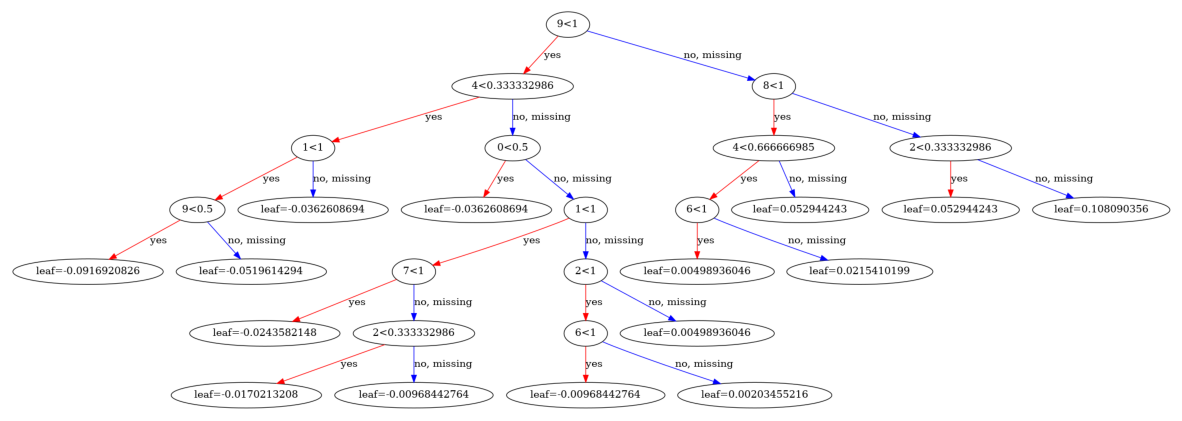

In [6]:
fig, ax = plt.subplots(figsize=(15, 15))

plot_tree(model, ax=ax, num_trees=0)

In [7]:
X_test[:10]

,0,1,2,3,4,5,6,7,8,9
50,0.0,0.0,0.000000,0.5,0.000000,0.0,1.0,1.0,0.0,0.0
153,0.5,0.5,0.000000,0.5,0.666667,0.0,0.5,0.5,0.5,0.0
223,1.0,0.5,0.666667,0.0,0.000000,0.0,0.0,0.5,1.0,0.0
189,1.0,1.0,0.333333,0.0,0.333333,1.0,1.0,1.0,1.0,1.0
5,0.5,0.5,0.666667,0.5,1.000000,1.0,0.5,0.5,0.5,0.0
172,1.0,1.0,1.000000,0.0,1.000000,1.0,1.0,1.0,1.0,0.5
26,0.0,0.5,0.333333,1.0,0.666667,1.0,0.5,0.0,0.0,0.5
16,0.5,0.0,0.333333,0.5,0.666667,0.0,0.5,0.5,1.0,0.0
88,0.5,1.0,1.000000,0.0,0.666667,1.0,0.5,0.0,0.5,0.5
204,0.0,0.5,0.333333,1.0,0.666667,1.0,0.5,0.0,0.0,0.5


In [8]:
changed = []
for i in range(30):
    for j in range(criteria_nr - 1):
        b_X_test = X_test.iloc[[i]].copy()
        b_X_test.at[b_X_test.index[0], j] = b_X_test.at[b_X_test.index[0], j] + 0.1
        b_y_pred = model.predict(b_X_test)
        if b_y_pred[0] != y_test_pred[i]:
            changed.append((i, j, 0.1))
            
        b_X_test.at[b_X_test.index[0], j] = b_X_test.at[b_X_test.index[0], j] - 0.2
        b_y_pred = model.predict(b_X_test)
        if b_y_pred[0] != y_test_pred[i]:
            changed.append((i, j, -0.1))

print("Changed predictions:")
for i, j, change in changed:    
    print(f"Sample {i}, Criterion {j}, Change: {change}")

Changed predictions:
Sample 8, Criterion 0, Change: -0.1
Sample 8, Criterion 1, Change: -0.1
Sample 20, Criterion 0, Change: -0.1
Sample 20, Criterion 2, Change: -0.1
Sample 20, Criterion 4, Change: -0.1
Sample 20, Criterion 7, Change: -0.1
Sample 27, Criterion 0, Change: -0.1
Sample 27, Criterion 1, Change: -0.1
Sample 28, Criterion 1, Change: -0.1


In [9]:
b_X_test = X_test.iloc[[2]].copy()

b_X_test.at[b_X_test.index[0], 4] = 0.4

print(b_X_test)
b_y_pred = model.predict(b_X_test)
print(f"Original Prediction: {y_test_pred[2]}")
print(f"New Prediction: {b_y_pred[0]}")

       0    1         2    3    4    5    6    7    8    9
223  1.0  0.5  0.666667  0.0  0.4  0.0  0.0  0.5  1.0  0.0
Original Prediction: 0
New Prediction: 0


**SHAP**

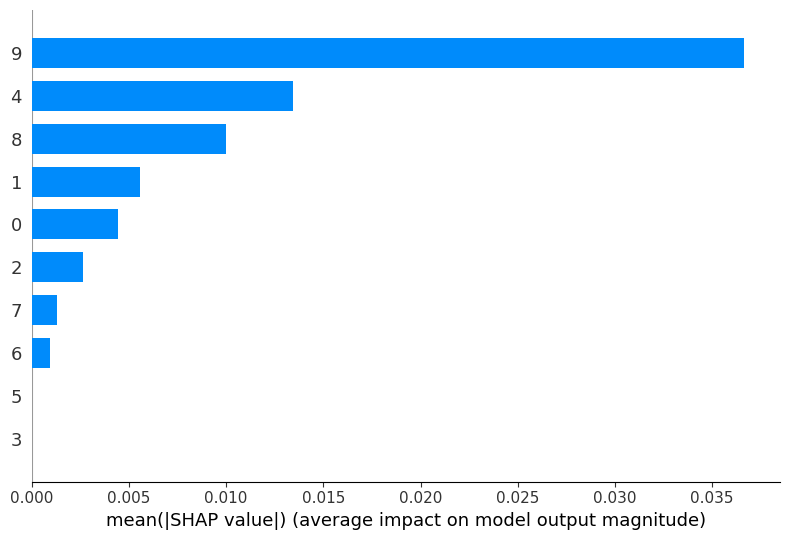

In [10]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, plot_type="bar")

**Partial dependence**

In [11]:
def partial_dependency(
    booster: xgb.Booster, X: np.ndarray, y: pd.Series, f_id: int
) -> Tuple[np.ndarray, np.ndarray]:
    """Calculate the partial dependency of a feature on the predicted outcome.
    Args:
        booster (xgb.Booster): The trained XGBoost model.
        X (np.ndarray): The input feature matrix.
        y (pd.Series): The target variable.
        f_id (int): The index of the feature for which the partial dependency is calculated.

    Returns:
        Tuple[np.ndarray, np.ndarray]: A tuple containing two numpy arrays:
        - grid: The values of the feature used for calculation.
        - y_pred: The predicted outcomes corresponding to each value in the grid.
    """
    grid = np.linspace(0, 1, 50)
    y_pred = np.zeros(len(grid))
    for i, val in enumerate(grid):
        X_temp = X.copy()
        X_temp[:, f_id] = val
        data = xgb.DMatrix(pd.DataFrame(X_temp))
        y_pred[i] = np.average(booster.predict(data))
    return grid, y_pred

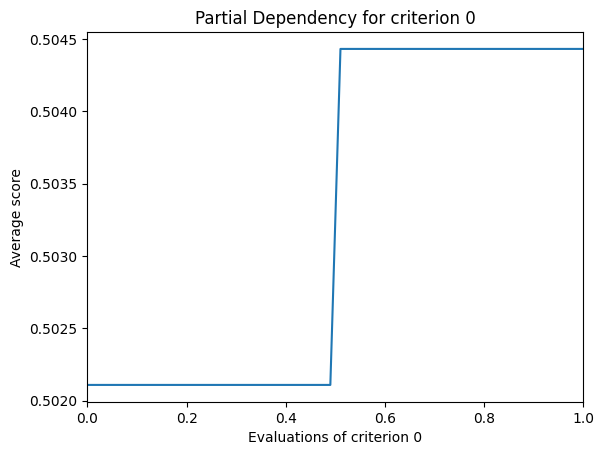

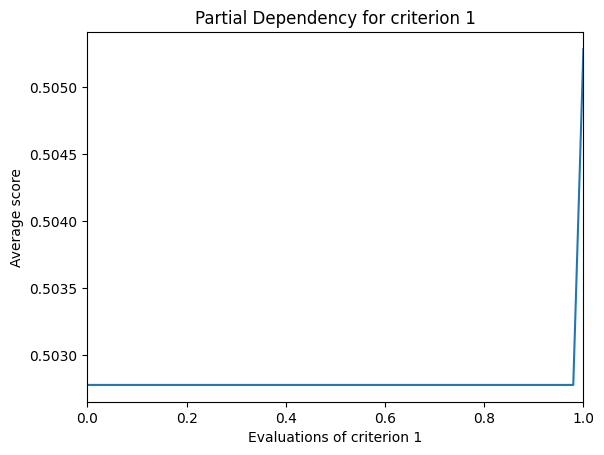

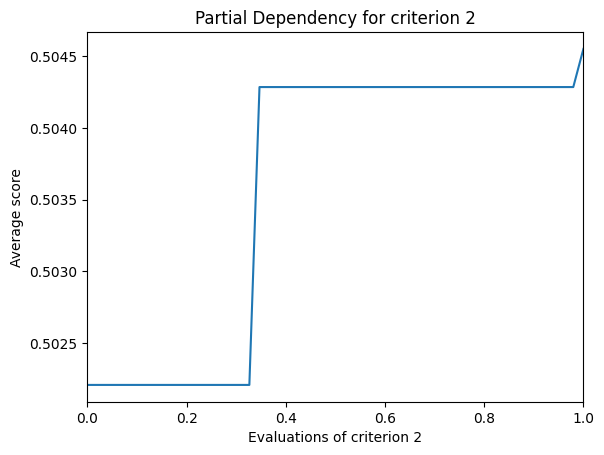

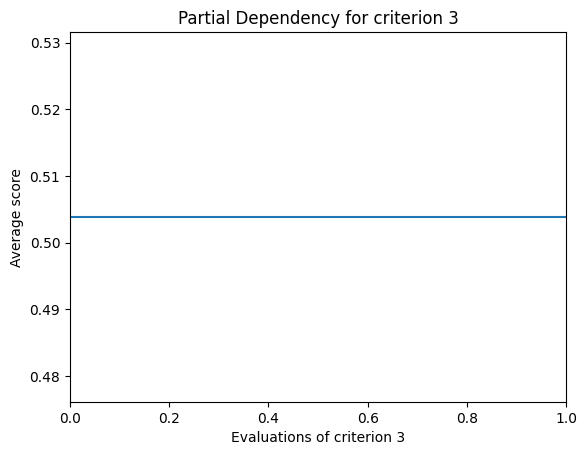

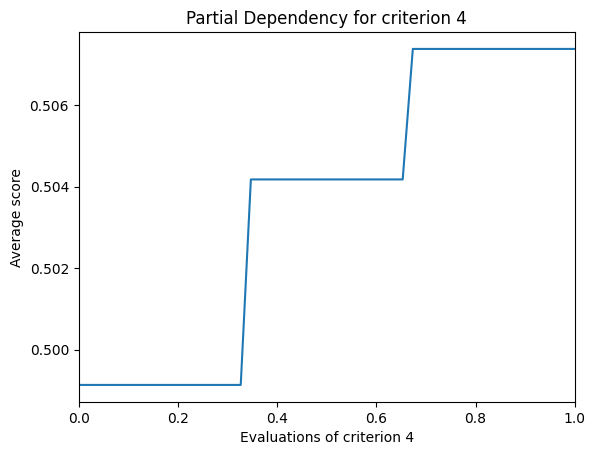

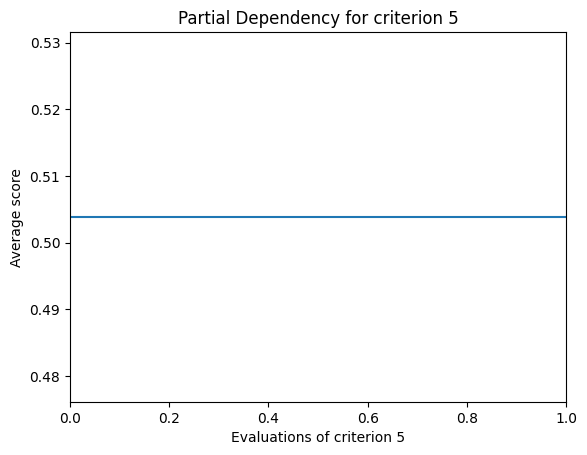

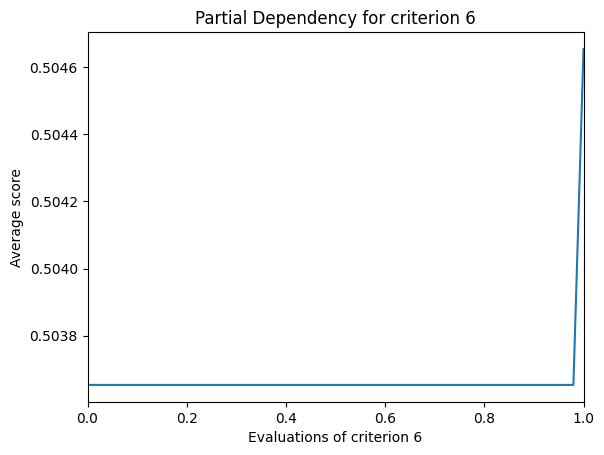

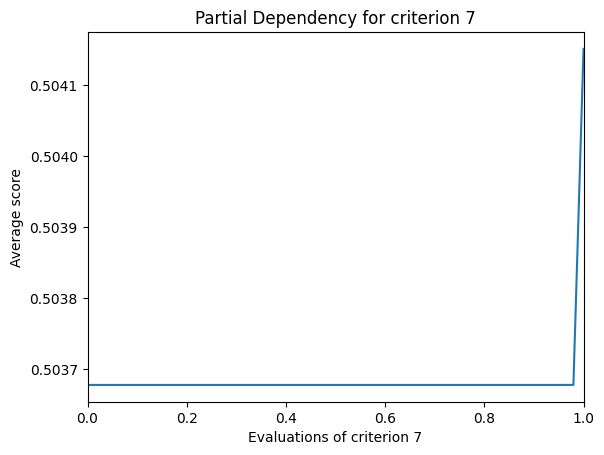

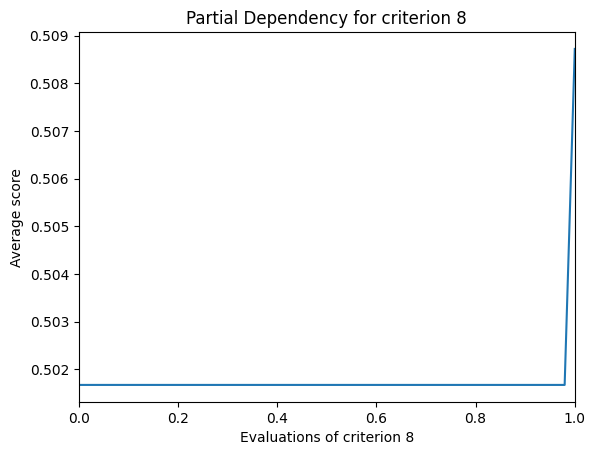

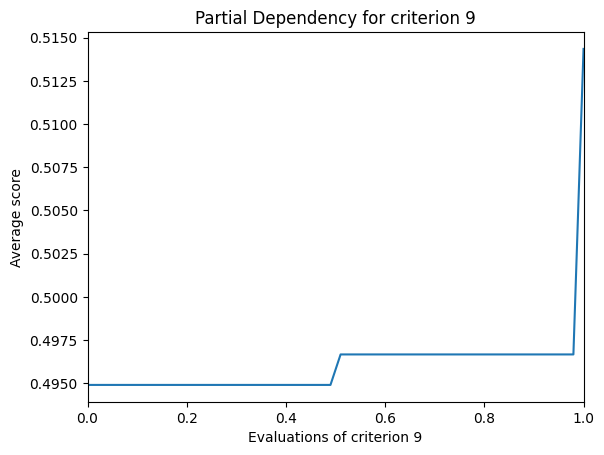

In [12]:
booster = model.get_booster()
grid = np.linspace(0, 1, 50)

for c in range(criteria_nr):
    grid, y_pred = partial_dependency(booster, X_train.values, y_train, c)
    fig, ax = plt.subplots()
    ax.plot(grid, y_pred)
    ax.set_xlim(0, 1)
    ax.set_title(f"Partial Dependency for criterion {c}")
    ax.set_xlabel(f"Evaluations of criterion {c}")
    ax.set_ylabel("Average score")

### UTADIS

**Import modules**

In [13]:
import torch
from utils import *
from uta import Uta
from norm_layer import NormLayer

**Load data**

In [14]:
path = "data/social_workers_decisions.csv"
data = pd.read_csv(path, header=None)
target_map = {1: 0, 2: 0, 3: 0, 4: 1, 5: 1}
num_criteria = criteria_nr
data_input = data.iloc[:, :num_criteria]
data_target = data[num_criteria].apply(lambda x: target_map[x])

data_input = data_input.values.reshape(-1, 1, num_criteria)

X_train, X_test, y_train, y_test = train_test_split(
    data_input, data_target.values, test_size=0.2, random_state=1234
)

train_dataloader = CreateDataLoader(X_train, y_train)
test_dataloader = CreateDataLoader(X_test, y_test)

**Train model**

In [15]:
uta = Uta(num_criteria, 30)
PATH = "uta.pt2"

model = NormLayer(uta, num_criteria)
(
    best_acc,
    best_auc,
    best_f1,
    stats_train,
    stats_test,
) = Train(model, train_dataloader, test_dataloader, PATH,epoch_nr=200,lr =0.0001,slope_decrease=True)

100%|██████████| 200/200 [00:01<00:00, 116.03it/s]


**Metrics**

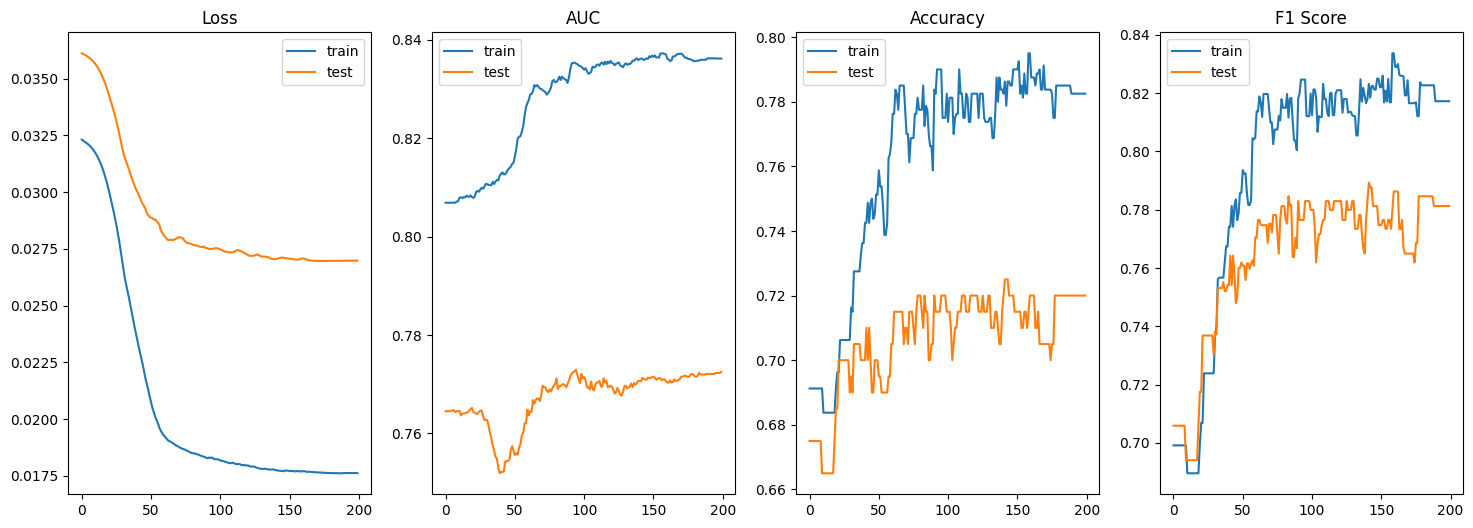

In [16]:
fig = plt.figure(figsize=(18,6))

ax = fig.add_subplot(141)
ax.plot(stats_train.losses,label='train')
ax.plot(stats_test.losses,label='test')
ax.set_title('Loss')
ax.legend()

ax = fig.add_subplot(142)
ax.plot(stats_train.auc_scores,label='train')
ax.plot(stats_test.auc_scores,label='test')
ax.set_title('AUC')
ax.legend()

ax = fig.add_subplot(143)
ax.plot(stats_train.acc_scores,label='train')
ax.plot(stats_test.acc_scores,label='test')
ax.set_title('Accuracy')
ax.legend()

ax = fig.add_subplot(144)
ax.plot(stats_train.f1_scores,label='train')
ax.plot(stats_test.f1_scores,label='test')
ax.set_title('F1 Score')
ax.legend()

**Marginal value functions**

In [17]:
checkpoint = torch.load(PATH)
model.load_state_dict(checkpoint["model_state_dict"])

<All keys matched successfully>

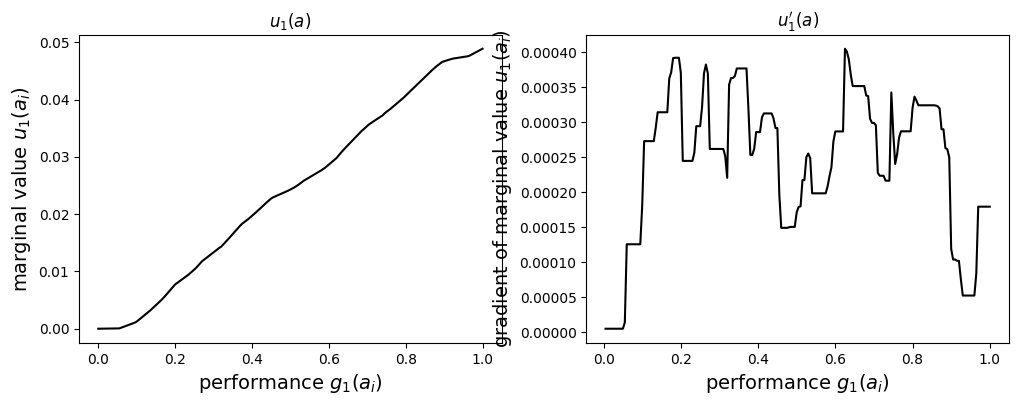

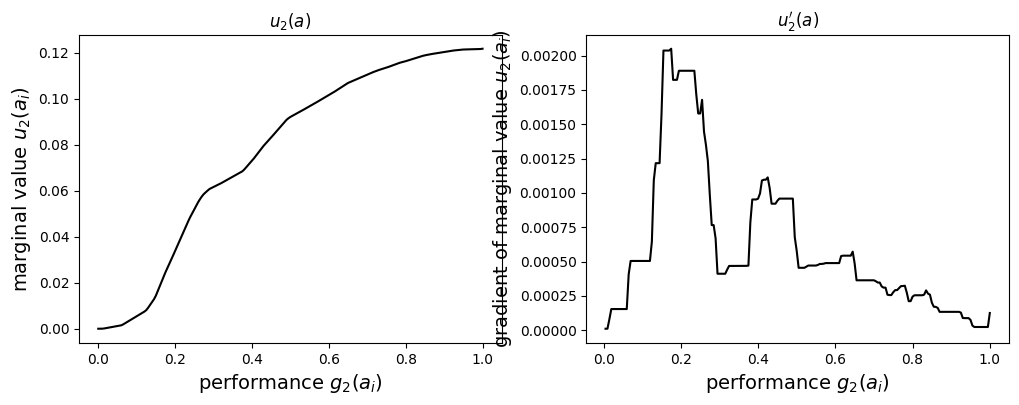

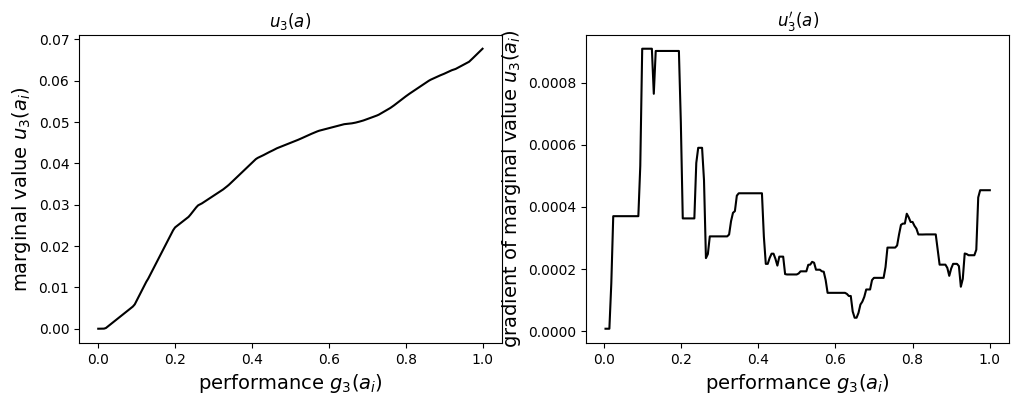

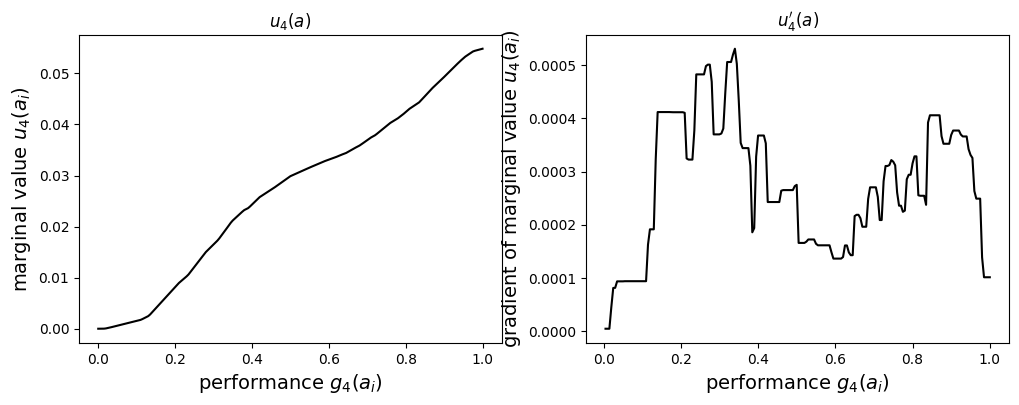

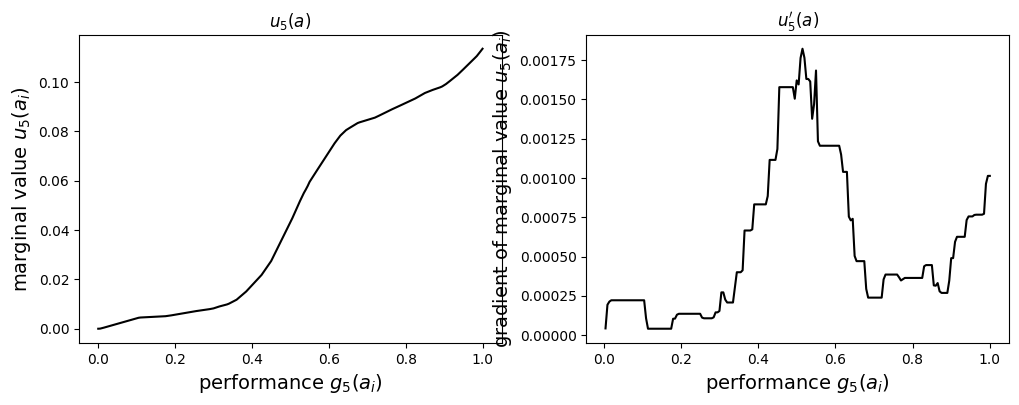

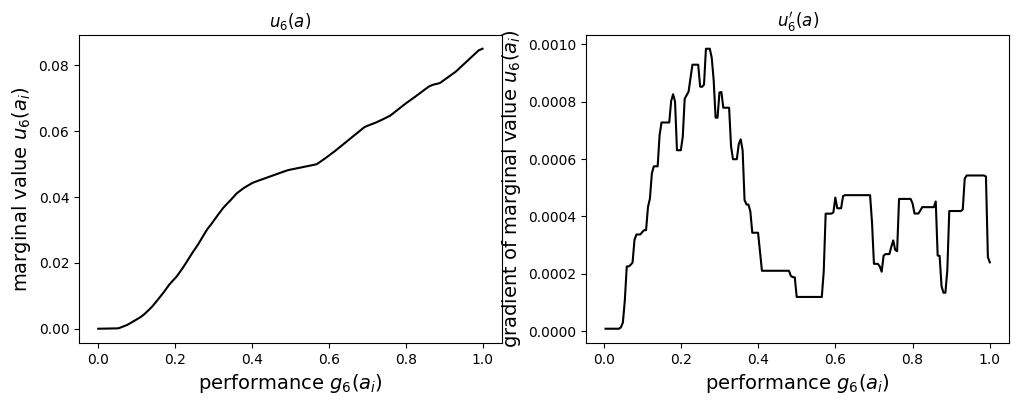

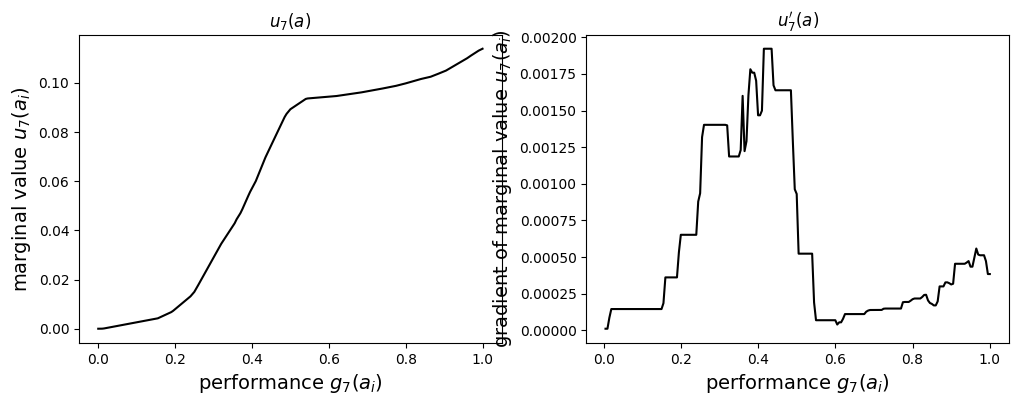

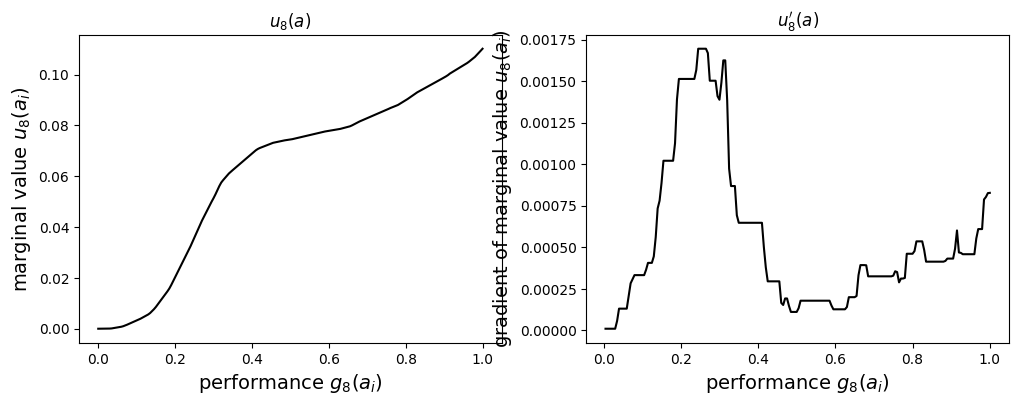

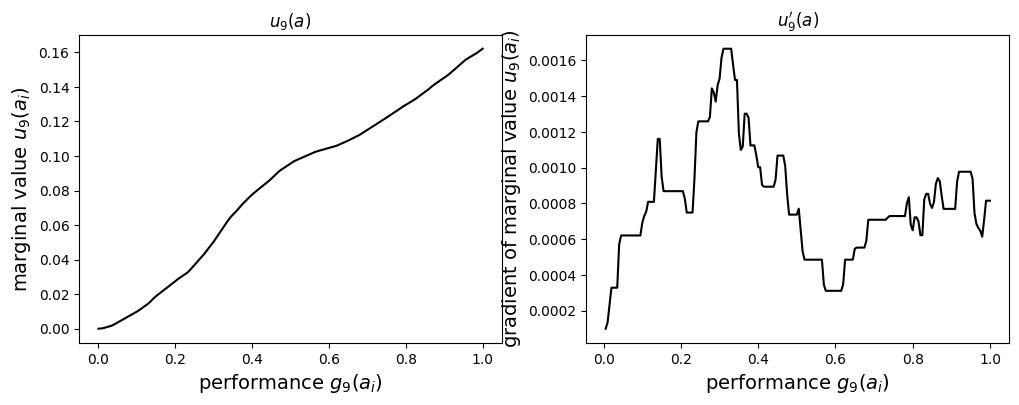

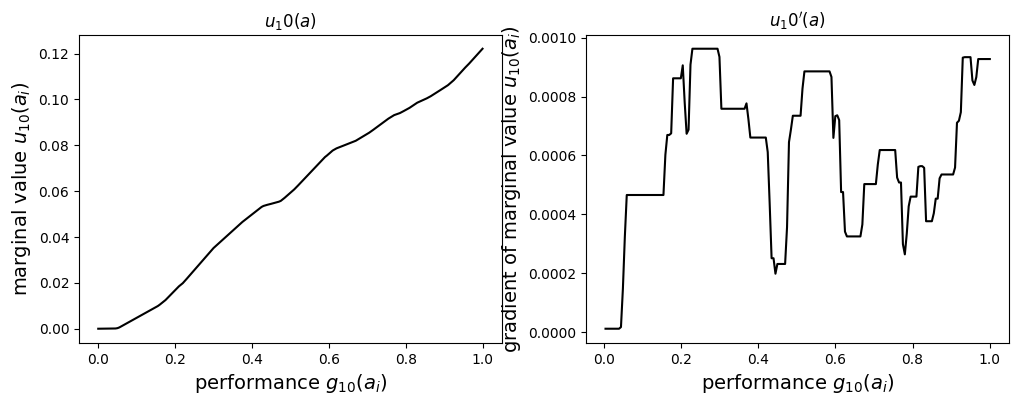

In [18]:
hook = Hook(model.method_instance.monotonic_layer, append_output)
xs = []
with torch.no_grad():
    for i in range(201):
        val = i / 200.0
        x = get_simple_input(val,num_criteria)
        xs.append(val)
        model(x)

outs = np.array(torch.stack(hook.stats)[:, 0].detach().cpu())
# We take every third value becouse the rest are from the normalization layer: velues for 0 and 1
outs = outs[::3] - outs[::3][0]
# Normalize the outputs to get proper weights of the criteria
outs = outs / outs[-1].sum()

for i in range(num_criteria):
    criterion_number = i + 1
    fig = plt.figure(figsize=(12,4))  
    ax = fig.add_subplot(121)
    ax.set_title(f'$u_{criterion_number}(a)$')
    ax.plot(xs, outs[:, i], color="black")
    ax.set_ylabel(f"marginal value $u_{{{criterion_number}}}(a_i)$", fontsize=14)
    ax.set_xlabel(f"performance $g_{{{criterion_number}}}(a_i)$", fontsize=14)

    ax = fig.add_subplot(1,2,2)
    ax.set_title(f"$u_{criterion_number}'(a)$")
    ax.plot(xs[1:], outs[1:, i]-outs[:-1, i], color="black")
    ax.set_ylabel(f"gradient of marginal value $u_{{{criterion_number}}}(a_i)$", fontsize=14)
    ax.set_xlabel(f"performance $g_{{{criterion_number}}}(a_i)$", fontsize=14)
    plt.show()

In [19]:
y_pred = np.array([model(torch.tensor(x, dtype=torch.float32)).detach().numpy() for x in X_test]).squeeze()
y_pred = (y_pred > 0.0).astype(int)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

Accuracy: 0.7200


**Decision boundary analysis using guided gradients**

In [20]:
def get_guided_gradients(model, input_tensor, target_class=1):
    input_tensor = input_tensor.clone().detach().requires_grad_(True)
    
    output = model(input_tensor)
    
    model.zero_grad()
    if output.shape[-1] > 1:
        target = output[0][target_class]
    else:
        target = output
        
    target.backward()
    
    gradients = input_tensor.grad.data
    
    return (gradients, target.item())

for i in range(3):
    var_input = X_test[i]
    var_input_tensor = torch.Tensor(var_input).unsqueeze(0)
    grads, target = get_guided_gradients(model, var_input_tensor)
    
    target = int(target > 0)

    print("="*20)
    print(f"Variant {i} Influence (Gradients):")
    print(grads)
    print(f"Variant {i} Target Value:")
    print(f"Predicted: {target}")
    print(f"Actual: {y_test[i]}")

Variant 0 Influence (Gradients):
tensor([[[0.0358, 0.0022, 0.0759, 0.0010, 0.0941, 0.0446, 0.1047, 0.1657,
          0.1475, 0.1470]]])
Variant 0 Target Value:
Predicted: 1
Actual: 1
Variant 1 Influence (Gradients):
tensor([[[0.0357, 0.0909, 0.0907, 0.0332, 0.0415, 0.0446, 0.1047, 0.0223,
          0.1630, 0.1855]]])
Variant 1 Target Value:
Predicted: 1
Actual: 1
Variant 2 Influence (Gradients):
tensor([[[0.0357, 0.0909, 0.0759, 0.0203, 0.0415, 0.0446, 0.1047, 0.1657,
          0.0027, 0.1470]]])
Variant 2 Target Value:
Predicted: 1
Actual: 1


In [21]:
b_X_test = X_test[0].copy()
b_X_test[0, 8] = 0.11
print(b_X_test)
b_y_pred = model(torch.tensor(b_X_test, dtype=torch.float32)).detach().numpy()
print(f"Original Prediction: {y_pred[0]}")
print(f"New Prediction: {int(b_y_pred > 0)}")

[[1.       0.       0.333333 0.       0.666667 1.       0.5      1.
  0.11     0.5     ]]
Original Prediction: 1
New Prediction: 1


/tmp/ipykernel_1125/2598545801.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"New Prediction: {int(b_y_pred > 0)}")


### Neural Network (Blackbox)

**Import modules**

In [22]:
import torch.nn as nn

**Architecture**

In [26]:
class MCDANN(torch.nn.Module):
    def __init__(self, num_criteria):
        super(MCDANN, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(num_criteria, 128),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Linear(128, 64),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Linear(64, 32),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.layers(x)

**Training**

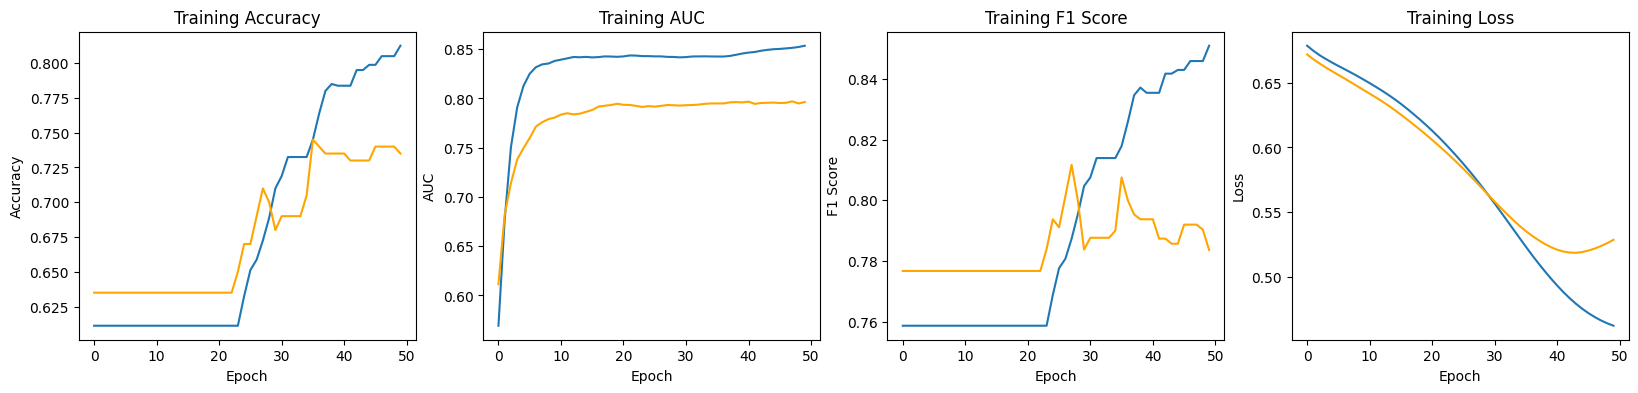

In [35]:
model = MCDANN(num_criteria)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)
criterion = nn.BCELoss()

epochs = 50

total_train_loss = np.array([])
total_train_acc = np.array([])
total_train_auc = np.array([])
total_train_f1 = np.array([])

total_test_loss = np.array([])
total_test_acc = np.array([])
total_test_auc = np.array([])
total_test_f1 = np.array([])

for epoch in range(epochs):
    train_loss = np.array([])
    train_acc = np.array([])
    train_auc = np.array([])
    train_f1 = np.array([])

    test_loss = np.array([])
    test_acc = np.array([])
    test_auc = np.array([])
    test_f1 = np.array([])

    for _, data in enumerate(train_dataloader, 0):
        inputs, targets = data
        model.train()
        optimizer.zero_grad()
        outputs = model(inputs).view(-1)

        y_true = targets.cpu().numpy().flatten()
        y_pred_labels = (outputs > 0.5).cpu().numpy().flatten()
        y_pred_probs = outputs.detach().cpu().numpy().flatten()

        loss = criterion(outputs, targets.float())

        train_loss = np.append(train_loss, [loss.item()])
        train_acc = np.append(train_acc, [accuracy_score(y_true, y_pred_labels)])
        train_auc = np.append(train_auc, [roc_auc_score(y_true, y_pred_probs)])
        train_f1 = np.append(train_f1, [f1_score(y_true, y_pred_labels)])

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    for _, data in enumerate(test_dataloader, 0):
        inputs, targets = data
        model.eval()
        with torch.no_grad():
            outputs = model(inputs).view(-1)
        
        y_true = targets.cpu().numpy().flatten()
        y_pred_labels = (outputs > 0.5).cpu().numpy().flatten()
        y_pred_probs = outputs.detach().cpu().numpy().flatten()

        loss = criterion(outputs, targets.float())

        test_loss = np.append(test_loss, [loss.item()])
        test_acc = np.append(test_acc, [accuracy_score(y_true, y_pred_labels)])
        test_auc = np.append(test_auc, [roc_auc_score(y_true, y_pred_probs)])
        test_f1 = np.append(test_f1, [f1_score(y_true, y_pred_labels)])

    total_train_loss = np.append(total_train_loss, [train_loss.mean()])
    total_train_acc = np.append(total_train_acc, [train_acc.mean()])
    total_train_auc = np.append(total_train_auc, [train_auc.mean()])
    total_train_f1 = np.append(total_train_f1, [train_f1.mean()])

    total_test_loss = np.append(total_test_loss, [test_loss.mean()])
    total_test_acc = np.append(total_test_acc, [test_acc.mean()])
    total_test_auc = np.append(total_test_auc, [test_auc.mean()])
    total_test_f1 = np.append(total_test_f1, [test_f1.mean()])

plt.figure(figsize=(20, 4))
plt.tight_layout()
plt.subplot(1, 4, 1)
plt.plot(total_train_acc, label='Train Accuracy')
plt.plot(total_test_acc, label='Test Accuracy', color='orange')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.subplot(1, 4, 2)
plt.plot(total_train_auc, label='Train AUC')
plt.plot(total_test_auc, label='Test AUC', color='orange')
plt.title('Training AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')

plt.subplot(1, 4, 3)
plt.plot(total_train_f1, label='Train F1 Score')
plt.plot(total_test_f1, label='Test F1 Score', color='orange')
plt.title('Training F1 Score')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')

plt.subplot(1, 4, 4)
plt.plot(total_train_loss, label='Train Loss')
plt.plot(total_test_loss, label='Test Loss', color='orange')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.show()

    

In [36]:
for i in range(3):
    var_input = X_test[i]
    var_input_tensor = torch.Tensor(var_input).unsqueeze(0)
    grads, target = get_guided_gradients(model, var_input_tensor)
    
    target = int(target > 0)

    print("="*20)
    print(f"Variant {i} Influence (Gradients):")
    print(grads)
    print(f"Variant {i} Target Value:")
    print(f"Predicted: {target}")
    print(f"Actual: {y_test[i]}")

Variant 0 Influence (Gradients):
tensor([[[ 0.0140,  0.1327,  0.5693,  0.0612,  0.3366,  0.1840,  0.1683,
          -0.0396,  0.1761,  0.2380]]])
Variant 0 Target Value:
Predicted: 1
Actual: 1
Variant 1 Influence (Gradients):
tensor([[[0.0186, 0.0152, 0.0531, 0.0033, 0.0356, 0.0034, 0.0308, 0.0187,
          0.0267, 0.0294]]])
Variant 1 Target Value:
Predicted: 1
Actual: 1
Variant 2 Influence (Gradients):
tensor([[[ 0.0942,  0.2311,  0.6996, -0.0966,  0.5372,  0.0217,  0.2970,
           0.0703,  0.4186,  0.2511]]])
Variant 2 Target Value:
Predicted: 1
Actual: 1


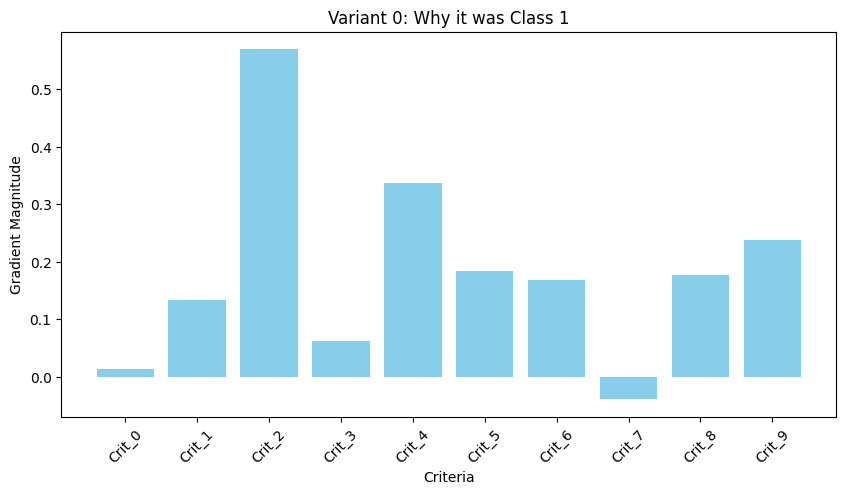

In [ ]:
def plot_gradients(grads, feature_names, title="Feature Influence"):
    grads = grads.flatten().cpu().numpy()
    
    plt.figure(figsize=(10, 5))
    plt.bar(feature_names, grads, color='skyblue')
    plt.title(title)
    plt.ylabel('Gradient Magnitude')
    plt.xlabel('Criteria')
    plt.xticks(rotation=45)
    plt.show()

var_input = X_test[0]
var_input_tensor = torch.Tensor(var_input).unsqueeze(0)
variant_0_grads, _ = get_guided_gradients(model, var_input_tensor)
feature_names = [f"Crit_{i}" for i in range(num_criteria)]
plot_gradients(variant_0_grads, feature_names, "Variant 0: Why it was Class 1")

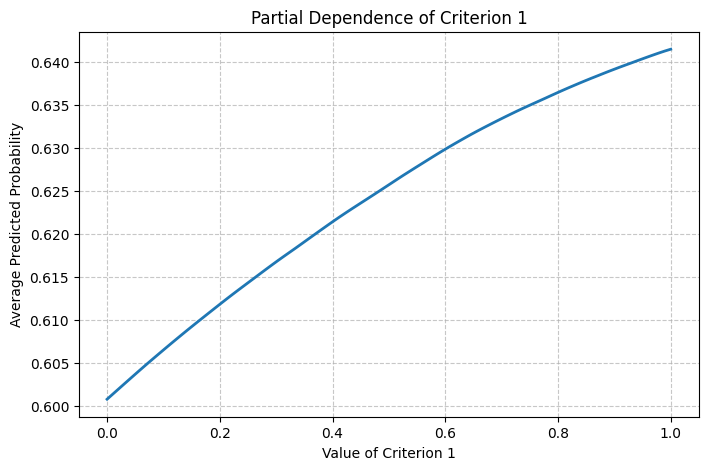

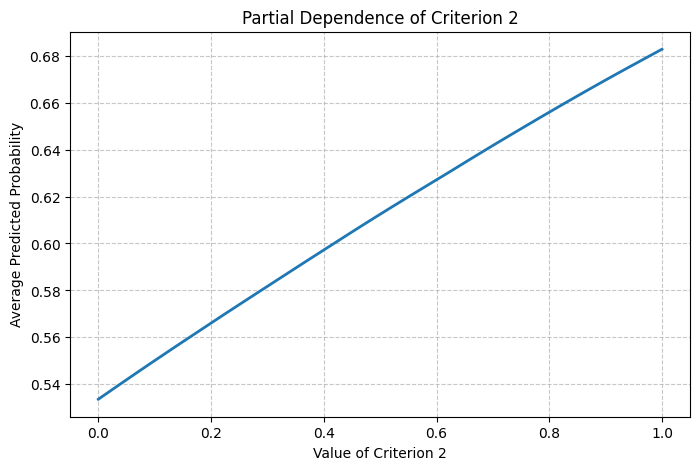

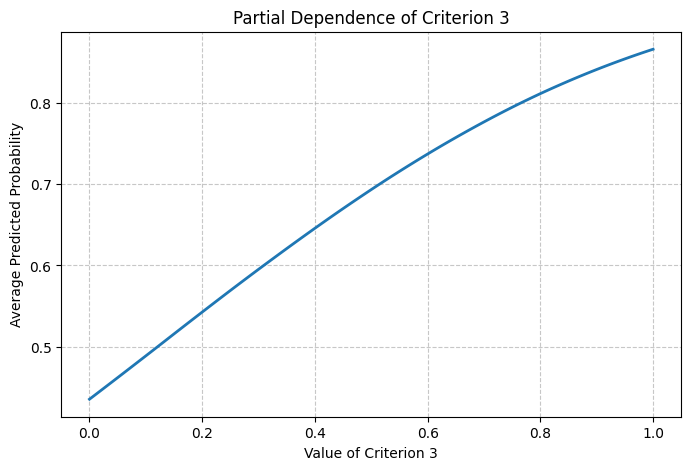

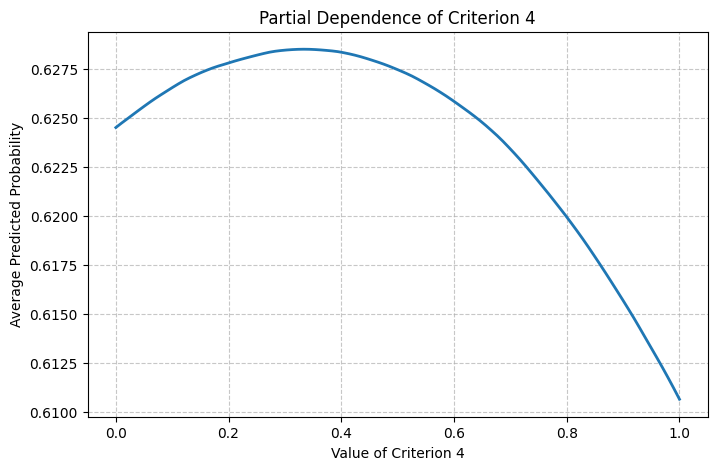

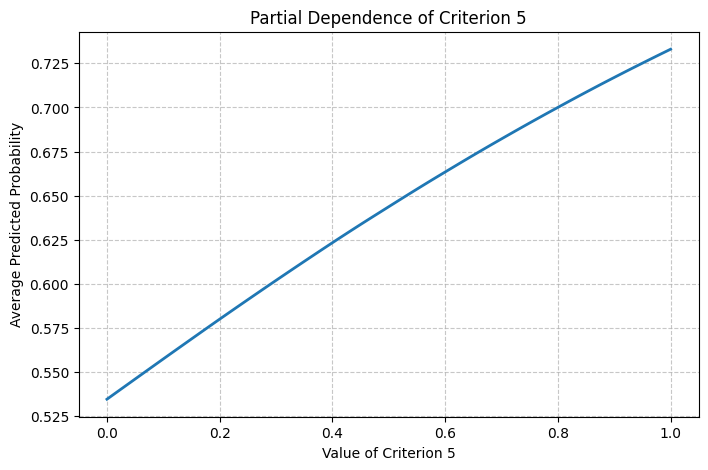

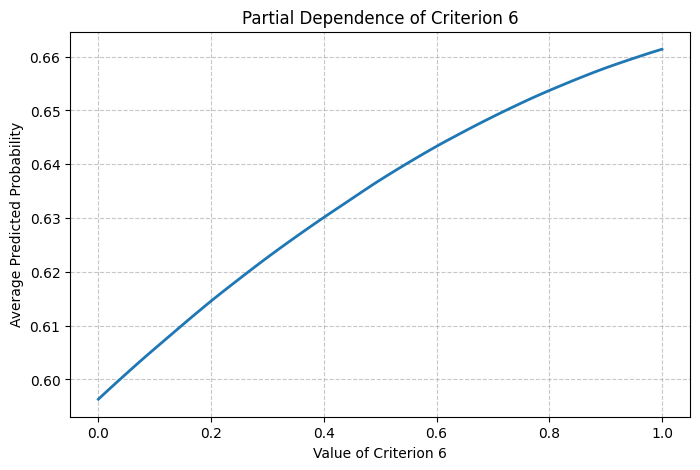

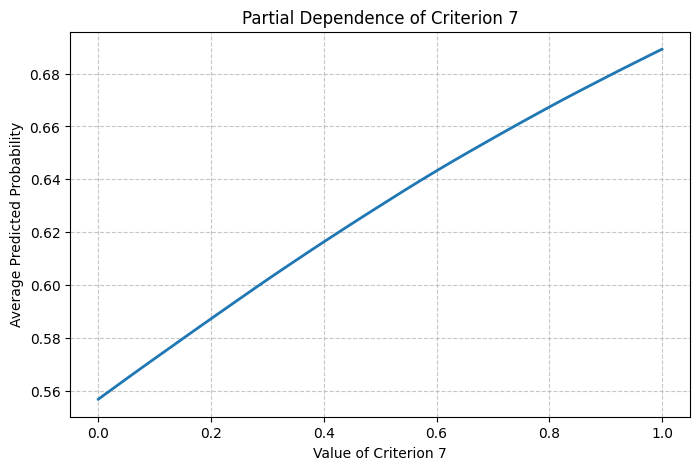

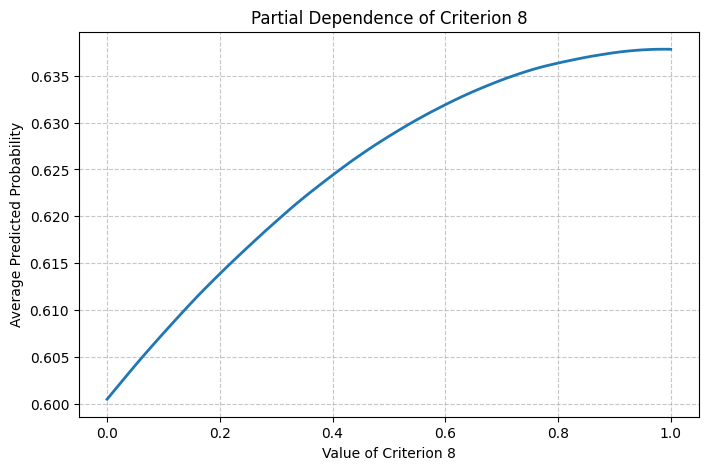

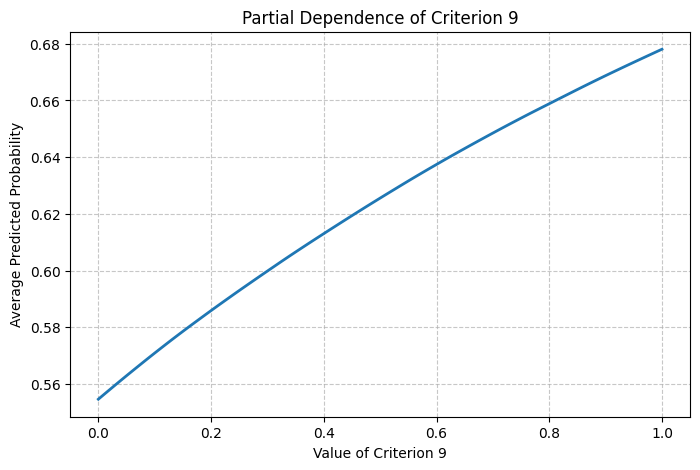

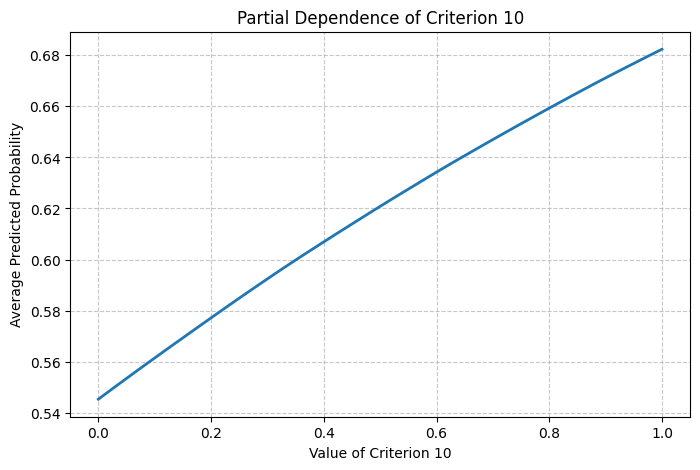

In [ ]:
def plot_pdp(model, X_train, feature_idx, feature_name):
    if not torch.is_tensor(X_train):
        X_tensor = torch.tensor(X_train.values if hasattr(X_train, 'values') else X_train).float()
    else:
        X_tensor = X_train.float()

    if len(X_tensor.shape) == 2:
        X_tensor = X_tensor.unsqueeze(1)

    sweep = torch.linspace(0, 1, 100)
    pdp_values = []

    model.eval()
    with torch.no_grad():
        for val in sweep:
            temp_X = X_tensor.clone()
            
            if len(temp_X.shape) == 3:
                temp_X[:, 0, feature_idx] = val
            else:
                temp_X[:, feature_idx] = val
            
            preds = model(temp_X)
            pdp_values.append(preds.mean().item())

    plt.figure(figsize=(8, 5))
    plt.plot(sweep.numpy(), pdp_values, linewidth=2)
    plt.title(f"Partial Dependence of {feature_name}")
    plt.xlabel(f"Value of {feature_name}")
    plt.ylabel("Average Predicted Probability")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

for i in range(num_criteria):
    plot_pdp(model, X_train, i, f"Criterion {i+1}")